# Simple E. coli Stress Response Network Analysis
## Validation Cyclic ID Algorithm on a 5-Gene Subgraph

---

### Overview

This notebook demonstrates the cyclic ID algorithm on a small stress response sub-network from an E. coli gene regulatory network, then moves to an analysis of the full network with valid pairs. This serves as:


1. **Validation** - Test algorithm on known biological feedback loops
2. **Interpretation** - Understand identifiability patterns in cyclic networks  
3. **Foundation** - Build intuition before scaling to full network

---

We examine 5 genes from E. coli's oxidative stress response:

| Gene | Function | Role |
|------|----------|------|
| **fnr** | Oxygen sensor | Detects low oxygen (anaerobic conditions) |
| **fur** | Iron homeostasis | Manages iron uptake and storage |
| **soxR** | Superoxide sensor | Detects superoxide radicals (O₂⁻) |
| **oxyR** | H₂O₂ sensor | Detects hydrogen peroxide |
| **soxS** | Stress response effector | Activates the defense genes |

**Key Insight:** Iron metabolism (fur) and oxidative stress (soxR, oxyR) are biochemically linked, creating feedback loops. See the graph structure below.

![Stress Response Network](visualizations/)

In [1]:
import random
import time

import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd
from IPython.display import Markdown, display
from y0.algorithm.identify import Unidentifiable
from y0.algorithm.identify.cyclic_id import cyclic_id
from y0.algorithm.ioscm.utils import (
    get_apt_order,
    get_graph_consolidated_districts,
    get_strongly_connected_components,
)
from y0.dsl import Variable
from y0.graph import NxMixedGraph

In [2]:
# ============================================================================
# Create the network
# ============================================================================

display(Markdown("## Step 1: Network Construction"))

nodes = ["fur", "fnr", "soxR", "oxyR", "soxS"]

edges = [
    ("oxyR", "fur"),
    ("fur", "soxR"),
    ("soxR", "oxyR"),
    ("soxR", "soxS"),
    ("fnr", "soxR"),
    ("fnr", "fnr"),  # self-loop
]

# Create NxMixedGraph directly
stress_graph = NxMixedGraph.from_edges(directed=edges)

display(
    Markdown(f"""
**Network Properties:**
- Nodes: {len(stress_graph.nodes())}
- Edges: {len(list(stress_graph.directed.edges()))}
- Key cycle: fur → soxR → oxyR → fur (3-gene feedback loop)
""")
)

display(Markdown("**Edge List:**"))
edges_df = pd.DataFrame(sorted(edges), columns=["Source", "Target"])
edges_df["Note"] = edges_df.apply(
    lambda row: "self-loop" if row["Source"] == row["Target"] else "", axis=1
)
display(edges_df)

## Step 1: Network Construction


**Network Properties:**
- Nodes: 5
- Edges: 6
- Key cycle: fur → soxR → oxyR → fur (3-gene feedback loop)


**Edge List:**

,Source,Target,Note
0,fnr,fnr,self-loop
1,fnr,soxR,
2,fur,soxR,
3,oxyR,fur,
4,soxR,oxyR,
5,soxR,soxS,


In [5]:
# ============================================================================
# Analyze graph structure
# ============================================================================

display(Markdown("## Step 2: Graph Analysis"))

# Get SCCs
sccs = get_strongly_connected_components(stress_graph)
sccs_sorted = sorted(sccs, key=len, reverse=True)

display(Markdown(f"**Strongly Connected Components:** {len(sccs)}"))
sccs_data = []
for i, scc in enumerate(sccs_sorted, 1):
    sccs_data.append(
        {"SCC": i, "Nodes": ", ".join(sorted([str(v) for v in scc])), "Size": len(scc)}
    )
sccs_df = pd.DataFrame(sccs_data)
display(sccs_df)

# Get consolidated districts
consolidated_districts = get_graph_consolidated_districts(stress_graph)
cds_sorted = sorted(consolidated_districts, key=len, reverse=True)

display(Markdown(f"\n**Consolidated Districts:** {len(consolidated_districts)}"))
cds_data = []
for i, cd in enumerate(cds_sorted, 1):
    cds_data.append(
        {"District": i, "Nodes": ", ".join(sorted([str(v) for v in cd])), "Size": len(cd)}
    )
cds_df = pd.DataFrame(cds_data)
display(cds_df)

## Step 2: Graph Analysis

**Strongly Connected Components:** 3

,SCC,Nodes,Size
0,1,"fur, oxyR, soxR",3
1,2,fnr,1
2,3,soxS,1



**Consolidated Districts:** 3

,District,Nodes,Size
0,1,"fur, oxyR, soxR",3
1,2,fnr,1
2,3,soxS,1


In [6]:
# ============================================================================
# Generate apt-order
# ============================================================================

display(Markdown("## Step 3: Apt-Order Generation"))

apt_order = get_apt_order(stress_graph)

display(Markdown("**Apt-order (total ordering of variables):**"))
apt_order_df = pd.DataFrame(
    {"Position": range(1, len(apt_order) + 1), "Variable": [str(v) for v in apt_order]}
)
display(apt_order_df)

display(Markdown(f"\n**Ordering:** {' < '.join([str(v) for v in apt_order])}"))

## Step 3: Apt-Order Generation

**Apt-order (total ordering of variables):**

,Position,Variable
0,1,fnr
1,2,fur
2,3,oxyR
3,4,soxR
4,5,soxS



**Ordering:** fnr < fur < oxyR < soxR < soxS

In [7]:
# ============================================================================
# Define and test the queries from the example graph
# ============================================================================

display(Markdown("## Step 4: Testing Queries"))

# Define queries
queries = [
    {
        "notation": "P(soxS | do(fnr))",
        "intervention_genes": ["fnr"],
        "outcome_genes": ["soxS"],
        "explanation": "fnr outside 3-gene cycle",
    },
    {
        "notation": "P(oxyR | do(fnr))",
        "intervention_genes": ["fnr"],
        "outcome_genes": ["oxyR"],
        "explanation": "fnr outside 3-gene cycle",
    },
    {
        "notation": "P(oxyR | do(fur))",
        "intervention_genes": ["fur"],
        "outcome_genes": ["oxyR"],
        "explanation": "Both in 3-gene cycle",
    },
    {
        "notation": "P(soxS | do(fnr, fur))",
        "intervention_genes": ["fnr", "fur"],
        "outcome_genes": ["soxS"],
        "explanation": "Interventions outside soxS district",
    },
    {
        "notation": "P(oxyR | do(fur, soxR))",
        "intervention_genes": ["fur", "soxR"],
        "outcome_genes": ["oxyR"],
        "explanation": "Both interventions in same cycle",
    },
    {
        "notation": "P(oxyR, soxS | do(fnr))",
        "intervention_genes": ["fnr"],
        "outcome_genes": ["oxyR", "soxS"],
        "explanation": "fnr outside cycle, both reachable",
    },
]

# Test each query
results = []

for idx, query_info in enumerate(queries, 1):
    display(Markdown(f"### Query {idx}: `{query_info['notation']}`"))

    # Create variables
    interventions = [Variable(g) for g in query_info["intervention_genes"]]
    outcomes = [Variable(g) for g in query_info["outcome_genes"]]

    # Time the computation
    start_time = time.time()

    try:
        result = cyclic_id(
            graph=stress_graph,
            outcomes=outcomes[0] if len(outcomes) == 1 else outcomes,
            interventions=interventions[0] if len(interventions) == 1 else interventions,
            ordering=apt_order,
        )

        result = "IDENTIFIABLE"
        estimand_str = str(result)
        error_msg = None

        display(
            Markdown(
                "**Result:** <span style='color: green; font-weight: bold;'>✓ IDENTIFIABLE</span>"
            )
        )
        display(Markdown(f"**Explanation:** {query_info['explanation']}"))
        display(Markdown(f"**Runtime:** {time.time() - start_time:.4f}s"))
        display(Markdown("**Estimand:**"))
        display(result)

    except Unidentifiable as e:
        result = "UNIDENTIFIABLE"
        estimand_str = None
        error_msg = str(e)

        display(
            Markdown(
                "**Result:** <span style='color: red; font-weight: bold;'>✗ UNIDENTIFIABLE</span>"
            )
        )
        display(Markdown(f"**Explanation:** {query_info['explanation']}"))
        display(Markdown(f"**Runtime:** {time.time() - start_time:.4f}s"))
        display(Markdown(f"**Error:** {error_msg[:200]}"))

    except Exception as e:
        result = "ERROR"
        estimand_str = None
        error_msg = f"{type(e).__name__}: {e!s}"

        display(
            Markdown("**Result:** <span style='color: orange; font-weight: bold;'>⚠ ERROR</span>")
        )
        display(Markdown(f"**Error:** {error_msg[:200]}"))

    runtime = time.time() - start_time

    # Store results
    results.append(
        {
            "query_num": idx,
            "notation": query_info["notation"],
            "interventions": ", ".join(query_info["intervention_genes"]),
            "outcomes": ", ".join(query_info["outcome_genes"]),
            "result": result,
            "explanation": query_info["explanation"],
            "runtime": runtime,
            "estimand_length": len(estimand_str) if estimand_str else None,
            "estimand": estimand_str,
            "error": error_msg,
        }
    )

    display(Markdown("---"))

results_df = pd.DataFrame(results)
display(Markdown("### Results Summary"))
display(results_df)

## Step 4: Testing Queries

### Query 1: `P(soxS | do(fnr))`

**Result:** <span style='color: green; font-weight: bold;'>✓ IDENTIFIABLE</span>

**Explanation:** fnr outside 3-gene cycle

**Runtime:** 0.0098s

...

**Estimand:**

'IDENTIFIABLE'

---

### Results Summary

,query_num,notation,interventions,outcomes,result,explanation,runtime,estimand_length,estimand,error
0,1,P(soxS | do(fnr)),fnr,soxS,IDENTIFIABLE,fnr outside 3-gene cycle,0.016593,12.0,IDENTIFIABLE,None
1,2,P(oxyR | do(fnr)),fnr,oxyR,IDENTIFIABLE,fnr outside 3-gene cycle,0.019110,12.0,IDENTIFIABLE,None
2,3,P(oxyR | do(fur)),fur,oxyR,UNIDENTIFIABLE,Both in 3-gene cycle,0.016157,NaN,None,Cannot identify P{oxyR} | do{fur})). District ...
3,4,"P(soxS | do(fnr, fur))","fnr, fur",soxS,UNIDENTIFIABLE,Interventions outside soxS district,0.018974,NaN,None,"Cannot identify P{soxS} | do{fnr, fur})). Dist..."
4,5,"P(oxyR | do(fur, soxR))","fur, soxR",oxyR,UNIDENTIFIABLE,Both interventions in same cycle,0.017683,NaN,None,"Cannot identify P{oxyR} | do{fur, soxR})). Dis..."
5,6,"P(oxyR, soxS | do(fnr))",fnr,"oxyR, soxS",IDENTIFIABLE,"fnr outside cycle, both reachable",0.052627,12.0,IDENTIFIABLE,None


In [8]:
# ============================================================================
# Summary statistics
# ============================================================================

display(Markdown("## Step 5: Summary Statistics"))

identifiable_count = (results_df["result"] == "IDENTIFIABLE").sum()
unidentifiable_count = (results_df["result"] == "UNIDENTIFIABLE").sum()
total_count = len(results_df)

# Overall statistics
overall_stats = pd.DataFrame(
    {
        "Metric": ["Total Queries", "Identifiable", "Unidentifiable", "Identifiable %"],
        "Value": [
            total_count,
            identifiable_count,
            unidentifiable_count,
            f"{100 * identifiable_count / total_count:.1f}%",
        ],
    }
)
display(Markdown("**Overall Results:**"))
display(overall_stats)

# Runtime statistics
runtime_stats = pd.DataFrame(
    {
        "Metric": ["Mean", "Median", "Min", "Max", "Total"],
        "Runtime (seconds)": [
            f"{results_df['runtime'].mean():.4f}",
            f"{results_df['runtime'].median():.4f}",
            f"{results_df['runtime'].min():.4f}",
            f"{results_df['runtime'].max():.4f}",
            f"{results_df['runtime'].sum():.4f}",
        ],
    }
)
display(Markdown("\n**Runtime Statistics:**"))
display(runtime_stats)

# Breakdown by query type
single_gene = results_df[~results_df["interventions"].str.contains(",")]
multi_gene = results_df[results_df["interventions"].str.contains(",")]

breakdown_stats = pd.DataFrame(
    {
        "Query Type": ["Single-gene", "Single-gene", "Multi-gene", "Multi-gene"],
        "Result": ["Identifiable", "Unidentifiable", "Identifiable", "Unidentifiable"],
        "Count": [
            (single_gene["result"] == "IDENTIFIABLE").sum(),
            (single_gene["result"] == "UNIDENTIFIABLE").sum(),
            (multi_gene["result"] == "IDENTIFIABLE").sum(),
            (multi_gene["result"] == "UNIDENTIFIABLE").sum(),
        ],
    }
)
display(Markdown("\n**Breakdown by Query Type:**"))
display(breakdown_stats)

## Step 5: Summary Statistics

**Overall Results:**

,Metric,Value
0,Total Queries,6
1,Identifiable,3
2,Unidentifiable,3
3,Identifiable %,50.0%



**Runtime Statistics:**

,Metric,Runtime (seconds)
0,Mean,0.0235
1,Median,0.0183
2,Min,0.0162
3,Max,0.0526
4,Total,0.1411



**Breakdown by Query Type:**

,Query Type,Result,Count
0,Single-gene,Identifiable,3
1,Single-gene,Unidentifiable,1
2,Multi-gene,Identifiable,0
3,Multi-gene,Unidentifiable,2


# Full E. coli Network Analysis with Valid Pairs
---

In [12]:
# ============================================================================
# Load E. coli network
# ============================================================================

display(Markdown("## Step 1: Load E. coli Network"))

# Load the GraphML file
ecoli_nx = nx.read_graphml("ecoli_full_network_no_small_rna.graphml")

display(
    Markdown(f"""
**Network loaded (NetworkX):**
- Nodes: {ecoli_nx.number_of_nodes():,}
- Edges: {ecoli_nx.number_of_edges():,}
- Is DAG: {nx.is_directed_acyclic_graph(ecoli_nx)}
""")
)

# Convert to NxMixedGraph for causal inference
ecoli_graph = NxMixedGraph.from_edges(directed=list(ecoli_nx.edges()))

display(Markdown("**✓ Converted to NxMixedGraph for causal inference**"))

# Get network properties
all_nodes = list(ecoli_graph.nodes())
display(Markdown(f"**Total nodes in y0 graph:** {len(all_nodes):,}"))

## Step 1: Load E. coli Network


**Network loaded (NetworkX):**
- Nodes: 2,976
- Edges: 9,211
- Is DAG: False


**✓ Converted to NxMixedGraph for causal inference**

**Total nodes in y0 graph:** 2,962

In [13]:
# ============================================================================
# Find all valid upstream→downstream pairs
# ============================================================================

display(Markdown("## Step 2: Finding All Valid Upstream→Downstream Pairs"))
display(Markdown("*Finding all pairs where intervention is upstream of target...*"))

# Find all valid pairs where intervention is upstream of target
valid_pairs = []

start_find = time.time()

for i, intervention_node in enumerate(all_nodes):
    if (i + 1) % 500 == 0:
        display(Markdown(f"Progress: {i + 1:,}/{len(all_nodes):,} nodes checked..."))

    # Get all descendants of this node (nodes reachable from intervention)
    try:
        descendants = nx.descendants(ecoli_nx, str(intervention_node))

        for target_node in descendants:
            # Don't include self (intervention == target)
            if str(intervention_node) != str(target_node):
                valid_pairs.append((str(intervention_node), str(target_node)))
    except:
        # Node might not be in graph or other issue
        continue

find_time = time.time() - start_find

display(
    Markdown(f"""
**✓ Search complete!**

**Results:**
- Total valid upstream→downstream pairs: **{len(valid_pairs):,}**
- Time to find pairs: {find_time:.2f}s ({find_time / 60:.2f} minutes)
- Average time per node: {find_time / len(all_nodes):.4f}s

**What this means:**
- These are all gene pairs where the intervention can causally affect the target
- Maximum possible queries to test: {len(valid_pairs):,}
""")
)

# Save valid pairs to file for later use
pairs_df = pd.DataFrame(valid_pairs, columns=["intervention", "target"])
pairs_df.to_csv("ecoli_valid_pairs.csv", index=False)
display(Markdown("**✓ Valid pairs saved to:** `ecoli_valid_pairs.csv`"))

display(Markdown("**First 10 valid pairs:**"))
display(pairs_df.head(10))

## Step 2: Finding All Valid Upstream→Downstream Pairs

*Finding all pairs where intervention is upstream of target...*

Progress: 500/2,962 nodes checked...

Progress: 1,000/2,962 nodes checked...

Progress: 1,500/2,962 nodes checked...

...

Progress: 2,500/2,962 nodes checked...


**✓ Search complete!**

**Results:**
- Total valid upstream→downstream pairs: **216,479**
- Time to find pairs: 1.35s (0.02 minutes)
- Average time per node: 0.0005s

**What this means:**
- These are all gene pairs where the intervention can causally affect the target
- Maximum possible queries to test: 216,479


**✓ Valid pairs saved to:** `ecoli_valid_pairs.csv`

**First 10 valid pairs:**

,intervention,target
0,aaeR,aaeA
1,aaeR,aaeB
2,aaeR,aaeX
3,accA,accD
4,accD,accA
5,accB,accC
6,acrR,ymdA
7,acrR,dcuB
8,acrR,paaX
9,acrR,yiiS


In [14]:
# ============================================================================
# Generate apt-order for the network
# ============================================================================

display(Markdown("## Step 3: Generate Apt-Order"))

apt_order_start = time.time()
apt_order = get_apt_order(ecoli_graph)
apt_order_time = time.time() - apt_order_start

display(
    Markdown(f"""
**✓ Apt-order generated!**
- Time to generate: {apt_order_time:.2f}s
- Total genes ordered: {len(apt_order):,}

**What this means:**
- This ordering respects all causal relationships in the network
- For any upstream→downstream pair, intervention comes before target in this ordering
- Used internally by cyclic_id for distribution factorization (Line 23)
- **Reused for all {len(valid_pairs):,} queries** (no need to regenerate)
""")
)

# Show first 10 genes in ordering
display(Markdown("**First 10 genes in apt-order:**"))
first_10 = [str(v) for v in apt_order[:10]]
display(Markdown(f"`{' < '.join(first_10)}`"))

# Show last 10 genes in ordering
display(Markdown("**Last 10 genes in apt-order:**"))
last_10 = [str(v) for v in apt_order[-10:]]
display(Markdown(f"`{' < '.join(last_10)}`"))

## Step 3: Generate Apt-Order


**✓ Apt-order generated!**
- Time to generate: 0.30s
- Total genes ordered: 2,961

**What this means:**
- This ordering respects all causal relationships in the network
- For any upstream→downstream pair, intervention comes before target in this ordering
- Used internally by cyclic_id for distribution factorization (Line 23)
- **Reused for all 216,479 queries** (no need to regenerate)


**First 10 genes in apt-order:**

`glaR < modE < glrR < racR < yidZ < kdpE < alpA < btsR < nsrR < ulaR`

**Last 10 genes in apt-order:**

`hyaF < appA < hyaC < hyaD < appX < hyaA < appC < hyaB < hyaE < appB`

# First Set of Benchmarking: 5, 50, 500 Valid Pairs tested Randomly

In [ ]:
# ============================================================================
# Benchmark 1: 5 random pairs
# ============================================================================

display(Markdown("## Step 4: Benchmarking - Sample Sizes"))
display(Markdown("### Test 1: 5 Random Pairs"))

# Sample 5 random pairs
sample_size = 5
sample_pairs = random.sample(valid_pairs, sample_size)

display(Markdown(f"**Testing {sample_size} random upstream→downstream pairs...**"))

# Test queries
results = []

for idx, (interv_name, target_name) in enumerate(sample_pairs, 1):
    display(Markdown(f"**Query {idx}/{sample_size}:** `P({target_name} | do({interv_name}))`"))

    interv = Variable(interv_name)
    target = Variable(target_name)

    start_time = time.time()

    try:
        estimand = cyclic_id(
            graph=ecoli_graph, outcomes=target, interventions=interv, ordering=apt_order
        )

        identifiable = True
        estimand_str = str(estimand)
        error_msg = None

        display(Markdown(f"  ✓ **IDENTIFIABLE** (runtime: {time.time() - start_time:.4f}s)"))

    except Unidentifiable as e:
        identifiable = False
        estimand_str = None
        error_msg = str(e)

        display(Markdown(f"  ✗ **UNIDENTIFIABLE** (runtime: {time.time() - start_time:.4f}s)"))

    except Exception as e:
        identifiable = False
        estimand_str = None
        error_msg = f"{type(e).__name__}: {e!s}"

        display(Markdown(f"  ⚠ **ERROR** (runtime: {time.time() - start_time:.4f}s)"))

    runtime = time.time() - start_time

    results.append(
        {
            "sample_size": sample_size,
            "pair_id": idx,
            "intervention": interv_name,
            "target": target_name,
            "identifiable": identifiable,
            "runtime_seconds": runtime,
            "estimand_length": len(estimand_str) if estimand_str else None,
            "estimand": estimand_str,
            "error_message": error_msg,
        }
    )

results_5_df = pd.DataFrame(results)

# Summary
identifiable_count = results_5_df["identifiable"].sum()
total_runtime = results_5_df["runtime_seconds"].sum()
avg_runtime = results_5_df["runtime_seconds"].mean()

display(
    Markdown(f"""
---
**✓ 5-pair sample complete!**

**Results:**
- Identifiable: {identifiable_count}/{sample_size} ({100 * identifiable_count / sample_size:.1f}%)
- Unidentifiable: {sample_size - identifiable_count}/{sample_size} ({100 * (sample_size - identifiable_count) / sample_size:.1f}%)

**Runtime:**
- Total: {total_runtime:.4f}s
- Average per query: {avg_runtime:.4f}s
- Min: {results_5_df["runtime_seconds"].min():.4f}s
- Max: {results_5_df["runtime_seconds"].max():.4f}s
""")
)

display(results_5_df)

# Save results
results_5_df.to_csv("ecoli_benchmark_5pairs.csv", index=False)
display(Markdown("**✓ Results saved:** `ecoli_benchmark_5pairs.csv`"))

In [ ]:
# ============================================================================
# Benchmark 2: 50 random pairs
# ============================================================================

display(Markdown("### Test 2: 50 Random Pairs"))

# Sample 50 random pairs (different from the 5-pair sample)
sample_size = 50
sample_pairs = random.sample(valid_pairs, sample_size)

display(Markdown(f"**Testing {sample_size} random upstream→downstream pairs...**"))
display(
    Markdown(f"*Estimated time: ~{sample_size * 29.13 / 60:.1f} minutes based on 5-pair average*")
)

# Test queries
results_50 = []
start_batch = time.time()

for idx, (interv_name, target_name) in enumerate(sample_pairs, 1):
    if idx % 10 == 0:
        elapsed = time.time() - start_batch
        avg_so_far = elapsed / idx
        remaining = (sample_size - idx) * avg_so_far
        display(
            Markdown(
                f"Progress: **{idx}/{sample_size}** | Elapsed: {elapsed / 60:.1f}min | Est. remaining: {remaining / 60:.1f}min"
            )
        )

    interv = Variable(interv_name)
    target = Variable(target_name)

    start_time = time.time()

    try:
        estimand = cyclic_id(
            graph=ecoli_graph, outcomes=target, interventions=interv, ordering=apt_order
        )

        identifiable = True
        estimand_str = str(estimand)
        error_msg = None

    except Unidentifiable as e:
        identifiable = False
        estimand_str = None
        error_msg = str(e)

    except Exception as e:
        identifiable = False
        estimand_str = None
        error_msg = f"{type(e).__name__}: {e!s}"

    runtime = time.time() - start_time

    results_50.append(
        {
            "sample_size": sample_size,
            "pair_id": idx,
            "intervention": interv_name,
            "target": target_name,
            "identifiable": identifiable,
            "runtime_seconds": runtime,
            "estimand_length": len(estimand_str) if estimand_str else None,
            "estimand": estimand_str[:500] if estimand_str else None,
            "error_message": error_msg[:500] if error_msg else None,
        }
    )

results_50_df = pd.DataFrame(results_50)

# Summary
identifiable_count = results_50_df["identifiable"].sum()
total_runtime = results_50_df["runtime_seconds"].sum()
avg_runtime = results_50_df["runtime_seconds"].mean()

display(
    Markdown(f"""
---
**✓ 50-pair sample complete!**

**Results:**
- Identifiable: {identifiable_count}/{sample_size} ({100 * identifiable_count / sample_size:.1f}%)
- Unidentifiable: {sample_size - identifiable_count}/{sample_size} ({100 * (sample_size - identifiable_count) / sample_size:.1f}%)

**Runtime:**
- Total: {total_runtime:.2f}s ({total_runtime / 60:.2f} minutes)
- Average per query: {avg_runtime:.4f}s
- Min: {results_50_df["runtime_seconds"].min():.4f}s
- Max: {results_50_df["runtime_seconds"].max():.4f}s

**Comparison with 5-pair sample:**
- 5-pair: 1/5 identifiable (20.0%)
- 50-pair: {identifiable_count}/{sample_size} identifiable ({100 * identifiable_count / sample_size:.1f}%)
""")
)

display(
    results_50_df[["pair_id", "intervention", "target", "identifiable", "runtime_seconds"]].head(20)
)

# Save results
results_50_df.to_csv("ecoli_benchmark_50pairs.csv", index=False)
display(Markdown("**✓ Results saved:** `ecoli_benchmark_50pairs.csv`"))

# Projection for 500 pairs
est_500_hours = (500 * avg_runtime) / 3600
display(
    Markdown(f"""
### Projection for 500-pair test:
- Estimated total time: **{est_500_hours:.2f} hours**
""")
)

In [ ]:
# ============================================================================
# Benchmark: 500 random pairs
# ============================================================================

from datetime import datetime

display(Markdown("### Test 3: 500 Random Pairs"))

# Sample 500 random pairs (different from 5 and 50)
sample_size = 500
sample_pairs = random.sample(valid_pairs, sample_size)

display(Markdown(f"**Testing {sample_size} random upstream→downstream pairs...**"))
display(
    Markdown(f"*Estimated time: ~{sample_size * 27.68 / 3600:.2f} hours based on 50-pair average*")
)
display(Markdown(f"*Started: {datetime.now().strftime('%H:%M:%S')}*"))

# Test queries
results_500 = []
start_batch = time.time()

for idx, (interv_name, target_name) in enumerate(sample_pairs, 1):
    # Progress updates every 50 queries
    if idx % 50 == 0:
        elapsed = time.time() - start_batch
        avg_so_far = elapsed / idx
        remaining = (sample_size - idx) * avg_so_far
        pct_complete = 100 * idx / sample_size

        # Count identifiable so far
        identifiable_so_far = sum([r["identifiable"] for r in results_500])
        pct_id = 100 * identifiable_so_far / idx if idx > 0 else 0

        display(
            Markdown(
                f"Progress: **{idx}/{sample_size} ({pct_complete:.1f}%)** | "
                f"Identifiable so far: {identifiable_so_far}/{idx} ({pct_id:.1f}%) | "
                f"Elapsed: {elapsed / 60:.1f}min | Est. remaining: {remaining / 60:.1f}min"
            )
        )

    interv = Variable(interv_name)
    target = Variable(target_name)

    start_time = time.time()

    try:
        estimand = cyclic_id(
            graph=ecoli_graph, outcomes=target, interventions=interv, ordering=apt_order
        )

        identifiable = True
        estimand_str = str(estimand)
        error_msg = None

    except Unidentifiable as e:
        identifiable = False
        estimand_str = None
        error_msg = str(e)

    except Exception as e:
        identifiable = False
        estimand_str = None
        error_msg = f"{type(e).__name__}: {e!s}"

    runtime = time.time() - start_time

    results_500.append(
        {
            "sample_size": sample_size,
            "pair_id": idx,
            "intervention": interv_name,
            "target": target_name,
            "identifiable": identifiable,
            "runtime_seconds": runtime,
            "estimand_length": len(estimand_str) if estimand_str else None,
            "estimand": estimand_str[:500] if estimand_str else None,  # Truncate
            "error_message": error_msg[:500] if error_msg else None,  # Truncate
        }
    )

# Final timing
total_elapsed = time.time() - start_batch

results_500_df = pd.DataFrame(results_500)

# Summary
identifiable_count = results_500_df["identifiable"].sum()
total_runtime = results_500_df["runtime_seconds"].sum()
avg_runtime = results_500_df["runtime_seconds"].mean()

display(
    Markdown(f"""
---
**✓ 500-pair sample complete!**

**Results:**
- Identifiable: {identifiable_count}/{sample_size} ({100 * identifiable_count / sample_size:.1f}%)
- Unidentifiable: {sample_size - identifiable_count}/{sample_size} ({100 * (sample_size - identifiable_count) / sample_size:.1f}%)

**Runtime:**
- Total: {total_runtime:.2f}s ({total_runtime / 60:.2f} minutes = {total_runtime / 3600:.2f} hours)
- Average per query: {avg_runtime:.4f}s
- Min: {results_500_df["runtime_seconds"].min():.4f}s
- Max: {results_500_df["runtime_seconds"].max():.4f}s

**Comparison across all samples:**
- 5-pair: 1/5 identifiable (20.0%)
- 50-pair: 10/50 identifiable (20.0%)
- 500-pair: {identifiable_count}/{sample_size} identifiable ({100 * identifiable_count / sample_size:.1f}%)

**Time completed:** {datetime.now().strftime("%H:%M:%S")}
""")
)

display(
    results_500_df[["pair_id", "intervention", "target", "identifiable", "runtime_seconds"]].head(
        30
    )
)

# Save results
results_500_df.to_csv("ecoli_benchmark_500pairs.csv", index=False)
display(Markdown("**✓ Results saved:** `ecoli_benchmark_500pairs.csv`"))

# Quick statistics
display(Markdown("### Quick Statistics"))
quick_stats = pd.DataFrame(
    {
        "Metric": ["Identifiable", "Unidentifiable", "Total", "% Identifiable"],
        "Count": [
            identifiable_count,
            sample_size - identifiable_count,
            sample_size,
            f"{100 * identifiable_count / sample_size:.2f}%",
        ],
    }
)
display(quick_stats)

## Second Set of Benchmarking: 10, 100, 1000 Valid Pairs tested Randomly

In [ ]:
# ============================================================================
# Benchmark 4: 10 random pairs
# ============================================================================

display(Markdown("### Test 4: 10 Random Pairs"))

# Sample 10 random pairs
sample_size = 10
random.seed(43)  # Different seed from other samples
sample_pairs = random.sample(valid_pairs, sample_size)

display(
    Markdown(f"""
**Testing {sample_size} random upstream→downstream pairs...**
- Estimated time: ~{sample_size * 23.99 / 60:.1f} minutes
- Started: {datetime.now().strftime("%H:%M:%S")}
""")
)

# Test queries
results_10 = []
start_batch = time.time()

for idx, (interv_name, target_name) in enumerate(sample_pairs, 1):
    display(Markdown(f"**Query {idx}/{sample_size}:** `P({target_name} | do({interv_name}))`"))

    interv = Variable(interv_name)
    target = Variable(target_name)

    start_time = time.time()

    try:
        estimand = cyclic_id(
            graph=ecoli_graph, outcomes=target, interventions=interv, ordering=apt_order
        )

        identifiable = True
        estimand_str = str(estimand)
        error_msg = None

        display(Markdown(f"  ✓ **IDENTIFIABLE** ({time.time() - start_time:.2f}s)"))

    except Unidentifiable as e:
        identifiable = False
        estimand_str = None
        error_msg = str(e)

        display(Markdown(f"  ✗ **UNIDENTIFIABLE** ({time.time() - start_time:.2f}s)"))

    except Exception as e:
        identifiable = False
        estimand_str = None
        error_msg = f"{type(e).__name__}: {e!s}"

        display(Markdown(f"  ⚠ **ERROR** ({time.time() - start_time:.2f}s)"))

    runtime = time.time() - start_time

    results_10.append(
        {
            "sample_size": sample_size,
            "pair_id": idx,
            "intervention": interv_name,
            "target": target_name,
            "identifiable": identifiable,
            "runtime_seconds": runtime,
            "estimand_length": len(estimand_str) if estimand_str else None,
            "estimand": estimand_str[:500] if estimand_str else None,
            "error_message": error_msg[:500] if error_msg else None,
        }
    )

results_10_df = pd.DataFrame(results_10)

# Summary
identifiable_count = results_10_df["identifiable"].sum()
total_runtime = results_10_df["runtime_seconds"].sum()
avg_runtime = results_10_df["runtime_seconds"].mean()

display(
    Markdown(f"""
---
**✓ 10-pair sample complete!**

**Results:**
- Identifiable: {identifiable_count}/{sample_size} ({100 * identifiable_count / sample_size:.1f}%)
- Unidentifiable: {sample_size - identifiable_count}/{sample_size} ({100 * (sample_size - identifiable_count) / sample_size:.1f}%)

**Runtime:**
- Total: {total_runtime:.2f}s ({total_runtime / 60:.2f} minutes)
- Average per query: {avg_runtime:.2f}s
- Min: {results_10_df["runtime_seconds"].min():.2f}s
- Max: {results_10_df["runtime_seconds"].max():.2f}s

**Time completed:** {datetime.now().strftime("%H:%M:%S")}

**Comparison:**
- 5-pair: 20.0%
- 10-pair: {100 * identifiable_count / sample_size:.1f}%
- 50-pair: 20.0%
- 500-pair: 10.4%
- 1000-pair: 12.0%
""")
)

display(results_10_df)

# Save results
results_10_df.to_csv("ecoli_benchmark_10pairs.csv", index=False)
display(Markdown("**✓ Results saved:** `ecoli_benchmark_10pairs.csv`"))

In [ ]:
# ============================================================================
# Benchmark: 100 random pairs
# ============================================================================

display(Markdown("### Test 5: 100 Random Pairs"))

# Sample 100 random pairs
sample_size = 100
random.seed(44)  # Different seed
sample_pairs = random.sample(valid_pairs, sample_size)

display(
    Markdown(f"""
**Testing {sample_size} random upstream→downstream pairs...**
- Estimated time: ~{sample_size * 23.99 / 60:.1f} minutes
- Started: {datetime.now().strftime("%H:%M:%S")}
""")
)

# Test queries
results_100 = []
start_batch = time.time()

for idx, (interv_name, target_name) in enumerate(sample_pairs, 1):
    # Progress updates every 10 queries
    if idx % 10 == 0:
        elapsed = time.time() - start_batch
        avg_so_far = elapsed / idx
        remaining = (sample_size - idx) * avg_so_far

        identifiable_so_far = sum([r["identifiable"] for r in results_100])
        pct_id = 100 * identifiable_so_far / idx

        display(
            Markdown(f"""
**Progress: {idx}/{sample_size}**
- Identifiable so far: {identifiable_so_far}/{idx} ({pct_id:.1f}%)
- Elapsed: {elapsed / 60:.1f}min | Est. remaining: {remaining / 60:.1f}min
""")
        )

    interv = Variable(interv_name)
    target = Variable(target_name)

    start_time = time.time()

    try:
        estimand = cyclic_id(
            graph=ecoli_graph, outcomes=target, interventions=interv, ordering=apt_order
        )

        identifiable = True
        estimand_str = str(estimand)
        error_msg = None

    except Unidentifiable as e:
        identifiable = False
        estimand_str = None
        error_msg = str(e)

    except Exception as e:
        identifiable = False
        estimand_str = None
        error_msg = f"{type(e).__name__}: {e!s}"

    runtime = time.time() - start_time

    results_100.append(
        {
            "sample_size": sample_size,
            "pair_id": idx,
            "intervention": interv_name,
            "target": target_name,
            "identifiable": identifiable,
            "runtime_seconds": runtime,
            "estimand_length": len(estimand_str) if estimand_str else None,
            "estimand": estimand_str[:500] if estimand_str else None,
            "error_message": error_msg[:500] if error_msg else None,
        }
    )

results_100_df = pd.DataFrame(results_100)

# Summary
identifiable_count = results_100_df["identifiable"].sum()
total_runtime = results_100_df["runtime_seconds"].sum()
avg_runtime = results_100_df["runtime_seconds"].mean()

display(
    Markdown(f"""
---
**✓ 100-pair sample complete!**

**Results:**
- Identifiable: {identifiable_count}/{sample_size} ({100 * identifiable_count / sample_size:.1f}%)
- Unidentifiable: {sample_size - identifiable_count}/{sample_size} ({100 * (sample_size - identifiable_count) / sample_size:.1f}%)

**Runtime:**
- Total: {total_runtime:.2f}s ({total_runtime / 60:.2f} minutes)
- Average per query: {avg_runtime:.2f}s
- Min: {results_100_df["runtime_seconds"].min():.2f}s
- Max: {results_100_df["runtime_seconds"].max():.2f}s

**Time completed:** {datetime.now().strftime("%H:%M:%S")}

**Full Comparison:**
- 5-pair: 20.0% (Series 1)
- 10-pair: 10.0% (Series 2)
- 50-pair: 20.0% (Series 1)
- 100-pair: {100 * identifiable_count / sample_size:.1f}% (Series 2)
- 500-pair: 10.4% (Series 1)
- 1000-pair: 12.0% (Series 2)
""")
)

display(results_100_df.head(20))

# Save results
results_100_df.to_csv("ecoli_benchmark_100pairs.csv", index=False)
display(Markdown("**✓ Results saved:** `ecoli_benchmark_100pairs.csv`"))

In [ ]:
# ============================================================================
# Benchmark: 1000 pairs with single gene interventions
# ============================================================================

display(Markdown("### Test 6: 1000 Random Pairs (Overnight Run)"))

import os

# Check for checkpoint file
checkpoint_file = "ecoli_benchmark_1000pairs_checkpoint.csv"
if os.path.exists(checkpoint_file):
    results_1000 = pd.read_csv(checkpoint_file).to_dict("records")
    display(
        Markdown(f"**📂 Resuming from checkpoint:** {len(results_1000)} queries already completed")
    )
else:
    results_1000 = []

# Sample 1000 random pairs
sample_size = 1000
random.seed(42)  # Fixed seed for reproducibility
sample_pairs = random.sample(valid_pairs, sample_size)

start_idx = len(results_1000)
display(
    Markdown(f"""
**Testing {sample_size} random upstream→downstream pairs...**
- Estimated time: ~{sample_size * 22.82 / 3600:.2f} hours
- Starting from query {start_idx + 1}
- Started: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}
- **Expected completion: ~{(datetime.now() + pd.Timedelta(seconds=(sample_size - start_idx) * 22.82)).strftime("%Y-%m-%d %H:%M:%S")}**
""")
)

start_batch = time.time()

for idx in range(start_idx, sample_size):
    interv_name, target_name = sample_pairs[idx]

    # Progress updates every 50 queries
    if (idx + 1) % 50 == 0 or idx == start_idx:
        elapsed = time.time() - start_batch
        if idx > start_idx:
            avg_so_far = elapsed / (idx + 1 - start_idx)
            remaining = (sample_size - idx - 1) * avg_so_far
            estimated_completion = datetime.now() + pd.Timedelta(seconds=remaining)
        else:
            remaining = (sample_size - idx - 1) * 22.82
            estimated_completion = datetime.now() + pd.Timedelta(seconds=remaining)

        pct_complete = 100 * (idx + 1) / sample_size
        identifiable_so_far = sum([r["identifiable"] for r in results_1000])
        pct_id = 100 * identifiable_so_far / (idx + 1) if idx >= 0 else 0

        display(
            Markdown(f"""
**Progress: {idx + 1}/{sample_size} ({pct_complete:.1f}%)**
- Identifiable so far: {identifiable_so_far}/{idx + 1} ({pct_id:.1f}%)
- Elapsed: {elapsed / 60:.1f} min ({elapsed / 3600:.2f} hr)
- Est. remaining: {remaining / 60:.1f} min ({remaining / 3600:.2f} hr)
- Est. completion: **{estimated_completion.strftime("%H:%M:%S")}**
- Current time: {datetime.now().strftime("%H:%M:%S")}
""")
        )

        # Save checkpoint every 50 queries
        if (idx + 1) % 50 == 0:
            pd.DataFrame(results_1000).to_csv(checkpoint_file, index=False)
            display(Markdown(f"💾 *Checkpoint saved at query {idx + 1}*"))

    interv = Variable(interv_name)
    target = Variable(target_name)

    start_time = time.time()

    try:
        estimand = cyclic_id(
            graph=ecoli_graph, outcomes=target, interventions=interv, ordering=apt_order
        )

        identifiable = True
        estimand_str = str(estimand)
        error_msg = None

    except Unidentifiable as e:
        identifiable = False
        estimand_str = None
        error_msg = str(e)

    except Exception as e:
        identifiable = False
        estimand_str = None
        error_msg = f"{type(e).__name__}: {e!s}"

    runtime = time.time() - start_time

    results_1000.append(
        {
            "sample_size": sample_size,
            "pair_id": idx + 1,
            "intervention": interv_name,
            "target": target_name,
            "identifiable": identifiable,
            "runtime_seconds": runtime,
            "estimand_length": len(estimand_str) if estimand_str else None,
            "estimand": estimand_str[:500] if estimand_str else None,
            "error_message": error_msg[:500] if error_msg else None,
        }
    )

# Final save
results_1000_df = pd.DataFrame(results_1000)

identifiable_count = results_1000_df["identifiable"].sum()
total_runtime = results_1000_df["runtime_seconds"].sum()
avg_runtime = results_1000_df["runtime_seconds"].mean()

display(
    Markdown(f"""
---
** 1000-PAIR SAMPLE COMPLETE!**

**Results:**
- Identifiable: {identifiable_count}/{sample_size} ({100 * identifiable_count / sample_size:.2f}%)
- Unidentifiable: {sample_size - identifiable_count}/{sample_size} ({100 * (sample_size - identifiable_count) / sample_size:.2f}%)

**Runtime:**
- Total: {total_runtime:.2f}s ({total_runtime / 60:.2f} min = {total_runtime / 3600:.2f} hr)
- Average per query: {avg_runtime:.2f}s
- Min: {results_1000_df["runtime_seconds"].min():.2f}s
- Max: {results_1000_df["runtime_seconds"].max():.2f}s

**Completed:** {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}
""")
)

display(results_1000_df.head(30))

# Save final results
results_1000_df.to_csv("ecoli_benchmark_1000pairs.csv", index=False)
display(Markdown("**Results saved:** `ecoli_benchmark_1000pairs.csv`"))

# Clean up checkpoint
if os.path.exists(checkpoint_file):
    os.remove(checkpoint_file)
    display(Markdown("*Checkpoint file removed*"))

# Multi-Gene Testing
---


In [15]:
# ============================================================================
# Multi-Gene Analysis: 5 Interventions → 1 Outcome
# ============================================================================


import random

from IPython.display import Markdown, display

display(Markdown("## Multi-Gene Analysis: 5 Interventions → 1 Target"))

# Parameters
n_interventions = 5
n_outcomes = 1
n_samples = 10
random_seed = 60

display(
    Markdown(f"""
**Test Parameters:**
- Number of interventions: {n_interventions}
- Number of outcomes: {n_outcomes}
- Sample size: {n_samples}
- Random seed: {random_seed}
""")
)

# Get all genes
all_genes = [str(node) for node in ecoli_graph.nodes()]

display(Markdown(f"**Network:** {len(all_genes)} genes available"))

# Generate random test cases
random.seed(random_seed)
test_cases = []

for i in range(n_samples):
    # Randomly select 5 genes to intervene on
    intervention_genes = random.sample(all_genes, n_interventions)

    # Randomly select 1 gene to observe (not in interventions)
    available_targets = [g for g in all_genes if g not in intervention_genes]
    target_gene = random.choice(available_targets)

    test_cases.append(
        {"case_id": i + 1, "interventions": intervention_genes, "outcomes": [target_gene]}
    )

display(Markdown(f"**✓ Generated {len(test_cases)} test cases**"))

# Show first 3 examples
display(Markdown("### Sample Test Cases:"))
for case in test_cases[:3]:
    interv_str = ", ".join(case["interventions"])
    outcome_str = ", ".join(case["outcomes"])
    display(Markdown(f"**Case {case['case_id']}:** P({outcome_str} | do({interv_str}))"))

# Test each case
results_5interv_1outcome = []
start_batch = time.time()

display(Markdown("\n### Testing Queries...\n"))

for case in test_cases:
    case_id = case["case_id"]
    interventions = [Variable(g) for g in case["interventions"]]
    outcomes = [Variable(g) for g in case["outcomes"]]

    # Create query string
    interv_str = ", ".join([str(v) for v in interventions])
    outcome_str = ", ".join([str(v) for v in outcomes])
    query_str = f"P({outcome_str} | do({interv_str}))"

    display(Markdown(f"**Case {case_id}/{n_samples}:** Testing `{query_str[:100]}...`"))

    start_time = time.time()

    try:
        estimand = cyclic_id(
            graph=ecoli_graph, outcomes=outcomes, interventions=interventions, ordering=apt_order
        )

        identifiable = True
        error_msg = None
        display(Markdown(f"  ✓ **IDENTIFIABLE** ({time.time() - start_time:.2f}s)"))

    except Unidentifiable as e:
        identifiable = False
        error_msg = str(e)[:200]
        display(Markdown(f"  ✗ **UNIDENTIFIABLE** ({time.time() - start_time:.2f}s)"))

    except Exception as e:
        identifiable = False
        error_msg = f"{type(e).__name__}: {e!s}"[:200]
        display(Markdown(f"  ⚠ **ERROR** ({time.time() - start_time:.2f}s)"))

    runtime = time.time() - start_time

    results_5interv_1outcome.append(
        {
            "case_id": case_id,
            "n_interventions": n_interventions,
            "n_outcomes": n_outcomes,
            "interventions": ", ".join(case["interventions"]),
            "outcomes": ", ".join(case["outcomes"]),
            "identifiable": identifiable,
            "runtime_seconds": runtime,
            "error_message": error_msg,
        }
    )

total_runtime = time.time() - start_batch

# Create DataFrame
results_5i1o_df = pd.DataFrame(results_5interv_1outcome)

# Summary
identifiable_count = results_5i1o_df["identifiable"].sum()
avg_runtime = results_5i1o_df["runtime_seconds"].mean()

display(
    Markdown(f"""
---
**✓ Test Complete!**

**Results:**
- Identifiable: {identifiable_count}/{n_samples} ({100 * identifiable_count / n_samples:.1f}%)
- Unidentifiable: {n_samples - identifiable_count}/{n_samples} ({100 * (n_samples - identifiable_count) / n_samples:.1f}%)

**Runtime:**
- Total: {total_runtime:.2f}s ({total_runtime / 60:.2f} minutes)
- Average per query: {avg_runtime:.2f}s
- Min: {results_5i1o_df["runtime_seconds"].min():.2f}s
- Max: {results_5i1o_df["runtime_seconds"].max():.2f}s

**Comparison:**
- Single intervention (1→1): 11.4% identifiable
- 2 interventions (2→1): ~0-5% identifiable (from earlier tests)
- 5 interventions (5→1): {100 * identifiable_count / n_samples:.1f}% identifiable

**Interpretation:** 
{"More interventions appear to DECREASE identifiability!" if identifiable_count < 2 else "Interesting pattern emerging..."}
""")
)

# Display results
display(Markdown("### Detailed Results:"))
display(results_5i1o_df[["case_id", "identifiable", "runtime_seconds"]])

# Save
# results_5i1o_df.to_csv('ecoli_5interventions_1outcome.csv', index=False)
# display(Markdown("**✓ Results saved:** `ecoli_5interventions_1outcome.csv`"))

## Multi-Gene Analysis: 5 Interventions → 1 Target


**Test Parameters:**
- Number of interventions: 5
- Number of outcomes: 1
- Sample size: 10
- Random seed: 60


**Network:** 2962 genes available

**✓ Generated 10 test cases**

### Sample Test Cases:

...

**Case 10/10:** Testing `P(caiT | do(nth, cspI, ftnA, pdxA, yfeX))...`

  ✓ **IDENTIFIABLE** (46.07s)


---
**✓ Test Complete!**

**Results:**
- Identifiable: 10/10 (100.0%)
- Unidentifiable: 0/10 (0.0%)

**Runtime:**
- Total: 340.73s (5.68 minutes)
- Average per query: 34.07s
- Min: 7.57s
- Max: 46.07s

**Comparison:**
- Single intervention (1→1): 11.4% identifiable
- 2 interventions (2→1): ~0-5% identifiable (from earlier tests)
- 5 interventions (5→1): 100.0% identifiable

**Interpretation:** 
Interesting pattern emerging...


### Detailed Results:

,case_id,identifiable,runtime_seconds
0,1,True,39.562237
1,2,True,35.338084
2,3,True,36.388449
3,4,True,35.984061
4,5,True,34.333191
5,6,True,33.465989
6,7,True,37.556989
7,8,True,7.566798
8,9,True,34.421593
9,10,True,46.073097


In [15]:
# ============================================================================
# Multi-Gene Analysis: 5 Interventions → 5 Outcomes with 10 samples
# ============================================================================

display(Markdown("## Multi-Gene Analysis: 5 Interventions → 5 Targets"))

display(
    Markdown("""
**Question:** What happens when we perturb 5 genes AND observe 5 targets simultaneously?

**Biological context:** 
- Quintuple knockout + multi-gene readout
- Maximum query complexity
- Tests extreme case: do multiple outcomes change the pattern?

**Hypothesis based on NotebookLM insights:** 
- 5 interventions "anchor" the network (break hub)
- Multiple outcomes shouldn't change identifiability much
- Should still see high identifiability (maybe 60-100%)

**Theory:** Interventions break confounding, outcomes are just additional variables to marginalize over.
""")
)

import random

# Parameters
n_interventions = 5
n_outcomes = 5
n_samples = 10
random_seed = 65

display(
    Markdown(f"""
**Test Parameters:**
- Number of interventions: {n_interventions}
- Number of outcomes: {n_outcomes}
- Sample size: {n_samples}
- Random seed: {random_seed}
""")
)

# Get all genes
all_genes = [str(node) for node in ecoli_graph.nodes()]

display(Markdown(f"**Network:** {len(all_genes)} genes available"))

# Generate random test cases
random.seed(random_seed)
test_cases_5x5 = []

for i in range(n_samples):
    # Randomly select 5 genes to intervene on
    intervention_genes = random.sample(all_genes, n_interventions)

    # Randomly select 5 genes to observe (not in interventions)
    available_targets = [g for g in all_genes if g not in intervention_genes]
    target_genes = random.sample(available_targets, n_outcomes)

    test_cases_5x5.append(
        {"case_id": i + 1, "interventions": intervention_genes, "outcomes": target_genes}
    )

display(Markdown(f"**✓ Generated {len(test_cases_5x5)} test cases**"))

# Show first 2 examples (abbreviated display)
display(Markdown("### Sample Test Cases:"))
for case in test_cases_5x5[:2]:
    interv_str = ", ".join(case["interventions"][:3]) + ", ..."
    outcome_str = ", ".join(case["outcomes"][:3]) + ", ..."
    display(Markdown(f"**Case {case['case_id']}:** P({outcome_str} | do({interv_str}))"))

# Test each case
results_5interv_5outcome = []
start_batch = time.time()

display(Markdown("\n### Testing Queries...\n"))

for case in test_cases_5x5:
    case_id = case["case_id"]
    interventions = [Variable(g) for g in case["interventions"]]
    outcomes = [Variable(g) for g in case["outcomes"]]

    # Create abbreviated display strings
    interv_display = ", ".join(case["interventions"][:2]) + ", ... (5 total)"
    outcome_display = ", ".join(case["outcomes"][:2]) + ", ... (5 total)"

    display(Markdown(f"**Case {case_id}/{n_samples}:**"))
    display(Markdown(f"  Interventions: {interv_display}"))
    display(Markdown(f"  Outcomes: {outcome_display}"))

    start_time = time.time()

    try:
        estimand = cyclic_id(
            graph=ecoli_graph, outcomes=outcomes, interventions=interventions, ordering=apt_order
        )

        identifiable = True
        error_msg = None
        display(Markdown(f"  ✓ **IDENTIFIABLE** ({time.time() - start_time:.2f}s)"))

    except Unidentifiable as e:
        identifiable = False
        error_msg = str(e)[:200]
        display(Markdown(f"  ✗ **UNIDENTIFIABLE** ({time.time() - start_time:.2f}s)"))
        display(Markdown(f"     Reason: {error_msg[:100]}..."))

    except Exception as e:
        identifiable = False
        error_msg = f"{type(e).__name__}: {e!s}"[:200]
        display(Markdown(f"  ⚠ **ERROR** ({time.time() - start_time:.2f}s)"))
        display(Markdown(f"     Error: {str(e)[:100]}..."))

    runtime = time.time() - start_time

    results_5interv_5outcome.append(
        {
            "case_id": case_id,
            "n_interventions": n_interventions,
            "n_outcomes": n_outcomes,
            "interventions": ", ".join(case["interventions"]),
            "outcomes": ", ".join(case["outcomes"]),
            "identifiable": identifiable,
            "runtime_seconds": runtime,
            "error_message": error_msg,
        }
    )

total_runtime = time.time() - start_batch

# Create DataFrame
results_5i5o_df = pd.DataFrame(results_5interv_5outcome)

# Summary
identifiable_count = results_5i5o_df["identifiable"].sum()
avg_runtime = results_5i5o_df["runtime_seconds"].mean()

print("Number of Identifiable Cases:", identifiable_count)
print("Average Runtime (seconds):", avg_runtime)

# save
results_5i5o_df.to_csv("ecoli_5x5_10samples.csv", index=False)

## Multi-Gene Analysis: 5 Interventions → 5 Targets


**Question:** What happens when we perturb 5 genes AND observe 5 targets simultaneously?

**Biological context:** 
- Quintuple knockout + multi-gene readout
- Maximum query complexity
- Tests extreme case: do multiple outcomes change the pattern?

**Hypothesis based on NotebookLM insights:** 
- 5 interventions "anchor" the network (break hub)
- Multiple outcomes shouldn't change identifiability much
- Should still see high identifiability (maybe 60-100%)

**Theory:** Interventions break confounding, outcomes are just additional variables to marginalize over.



**Test Parameters:**
- Number of interventions: 5
- Number of outcomes: 5
- Sample size: 10
- Random seed: 65


**Network:** 2962 genes available

**✓ Generated 10 test cases**

...

**Case 10/10:**

  Interventions: argF, cyoD, ... (5 total)

  Outcomes: pssA, nanR, ... (5 total)

  ✓ **IDENTIFIABLE** (64.65s)

Number of Identifiable Cases: 7
Average Runtime (seconds): 70.73779258728027


In [29]:
# ============================================================================
# Multi-Gene Benchmarking: 5 Interventions → 5 Outcomes (100 Samples)
# ============================================================================

display(Markdown("## Multi-Gene Benchmarking: 5→5 (100 Samples)"))

display(
    Markdown("""
**Test Configuration:**
- 5 interventions, 5 outcomes per query
- 100 random test cases
- Estimated time: ~100 minutes (1.7 hours)
- Purpose: Quick validation of 70% identifiability pattern

**This will provide:**
- Statistical validation (n=100)
- Convergence check
- Preparation for 1,000-sample run
""")
)


# Parameters
n_interventions = 5
n_outcomes = 5
n_samples = 100
random_seed = 100

display(
    Markdown(f"""
**Parameters:**
- Interventions: {n_interventions}
- Outcomes: {n_outcomes}
- Sample size: {n_samples}
- Random seed: {random_seed}
- Start time: {time.strftime("%Y-%m-%d %H:%M:%S")}
""")
)

# Get all genes
all_genes = [str(node) for node in ecoli_graph.nodes()]

# Generate test cases
random.seed(random_seed)
test_cases_100 = []

for i in range(n_samples):
    intervention_genes = random.sample(all_genes, n_interventions)
    available_targets = [g for g in all_genes if g not in intervention_genes]
    target_genes = random.sample(available_targets, n_outcomes)

    test_cases_100.append(
        {"case_id": i + 1, "interventions": intervention_genes, "outcomes": target_genes}
    )

display(Markdown(f"✓ Generated {len(test_cases_100)} test cases"))

# Run benchmark
results_5x5_100 = []
start_batch = time.time()

# Progress tracking
milestone_points = [10, 25, 50, 75, 100]
next_milestone = 0

for case in test_cases_100:
    case_id = case["case_id"]
    interventions = [Variable(g) for g in case["interventions"]]
    outcomes = [Variable(g) for g in case["outcomes"]]

    # Progress display at milestones
    if case_id in milestone_points:
        elapsed = time.time() - start_batch
        rate = case_id / elapsed
        remaining = (n_samples - case_id) / rate
        current_identifiable = sum([r["identifiable"] for r in results_5x5_100])
        current_rate = 100 * current_identifiable / len(results_5x5_100) if results_5x5_100 else 0

        display(
            Markdown(f"""
**Progress: {case_id}/{n_samples} ({100 * case_id / n_samples:.0f}%)**
- Elapsed: {elapsed / 60:.1f} min
- Remaining: ~{remaining / 60:.1f} min
- Current identifiability: {current_rate:.1f}%
        """)
        )

    start_time = time.time()

    try:
        estimand = cyclic_id(
            graph=ecoli_graph, outcomes=outcomes, interventions=interventions, ordering=apt_order
        )

        identifiable = True
        error_msg = None

    except Unidentifiable as e:
        identifiable = False
        error_msg = str(e)[:200]

    except Exception as e:
        identifiable = False
        error_msg = f"{type(e).__name__}: {e!s}"[:200]

    runtime = time.time() - start_time

    results_5x5_100.append(
        {
            "case_id": case_id,
            "n_interventions": n_interventions,
            "n_outcomes": n_outcomes,
            "interventions": ", ".join(case["interventions"]),
            "outcomes": ", ".join(case["outcomes"]),
            "identifiable": identifiable,
            "runtime_seconds": runtime,
            "error_message": error_msg,
        }
    )

total_runtime = time.time() - start_batch

# Create DataFrame
results_100_df = pd.DataFrame(results_5x5_100)

# Summary statistics
identifiable_count = results_100_df["identifiable"].sum()
unidentifiable_count = n_samples - identifiable_count
avg_runtime = results_100_df["runtime_seconds"].mean()
total_hours = total_runtime / 3600

display(
    Markdown(f"""
---
## ✓ 100-Sample Test Complete!

**Results:**
- **Identifiable:** {identifiable_count}/{n_samples} ({100 * identifiable_count / n_samples:.1f}%)
- **Unidentifiable:** {unidentifiable_count}/{n_samples} ({100 * unidentifiable_count / n_samples:.1f}%)

**Runtime Statistics:**
- Total time: {total_runtime:.0f}s ({total_runtime / 60:.1f} min / {total_hours:.2f} hours)
- Average per query: {avg_runtime:.2f}s
- Min: {results_100_df["runtime_seconds"].min():.2f}s
- Max: {results_100_df["runtime_seconds"].max():.2f}s

**Comparison to Initial Test (n=10):**
- Initial (seed=65): 7/10 (70%)
- Current (seed={random_seed}): {identifiable_count}/100 ({100 * identifiable_count / n_samples:.1f}%)
- Pattern: {"✓ CONSISTENT!" if abs(100 * identifiable_count / n_samples - 70) < 10 else "⚠ Different from initial test"}

""")
)

# Save results
results_100_df.to_csv("ecoli_5x5_100samples.csv", index=False)
display(Markdown("**✓ Results saved:** `ecoli_5x5_100samples.csv`"))

# Quick stats display
display(Markdown("### Sample Results (First 10):"))
display(results_100_df[["case_id", "identifiable", "runtime_seconds"]].head(10))

display(Markdown("### Sample Results (Last 10):"))
display(results_100_df[["case_id", "identifiable", "runtime_seconds"]].tail(10))

# Identifiability over time
display(Markdown("### Convergence Check:"))
running_rate = []
for i in range(10, n_samples + 1, 10):
    subset = results_100_df.iloc[:i]
    rate = 100 * subset["identifiable"].sum() / i
    running_rate.append({"samples": i, "identifiable_pct": rate})

convergence_df = pd.DataFrame(running_rate)
display(convergence_df)

display(
    Markdown(f"""
**Convergence Analysis:**
- Rate at 10 samples: {convergence_df.iloc[0]["identifiable_pct"]:.1f}%
- Rate at 50 samples: {convergence_df.iloc[4]["identifiable_pct"]:.1f}%
- Rate at 100 samples: {convergence_df.iloc[-1]["identifiable_pct"]:.1f}%
- Variance: {convergence_df["identifiable_pct"].std():.2f}%

**Interpretation:** {"Low variance suggests stable pattern - good for 1,000-sample run!" if convergence_df["identifiable_pct"].std() < 5 else "High variance - may need more samples"}
""")
)

print(f"\n{'=' * 80}")
print("100-SAMPLE RUN COMPLETE")
print(f"End time: {time.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"{'=' * 80}")

## Multi-Gene Benchmarking: 5→5 (100 Samples)


**Test Configuration:**
- 5 interventions, 5 outcomes per query
- 100 random test cases
- Estimated time: ~100 minutes (1.7 hours)
- Purpose: Quick validation of 70% identifiability pattern

**This will provide:**
- Statistical validation (n=100)
- Convergence check
- Preparation for 1,000-sample run



**Parameters:**
- Interventions: 5
- Outcomes: 5
- Sample size: 100
- Random seed: 100
- Start time: 2026-01-12 16:26:26


✓ Generated 100 test cases


**Progress: 10/100 (10%)**
- Elapsed: 15.0 min
- Remaining: ~135.3 min
- Current identifiability: 100.0%
        

...

,case_id,identifiable,runtime_seconds
90,91,True,46.642143
91,92,True,68.612354
92,93,True,60.495368
93,94,True,94.153341
94,95,True,85.718892
95,96,True,90.326558
96,97,True,66.379208
97,98,True,68.922245
98,99,True,53.127894
99,100,True,60.652218


### Convergence Check:

,samples,identifiable_pct
0,10,100.000000
1,20,90.000000
2,30,90.000000
3,40,85.000000
4,50,86.000000
5,60,88.333333
6,70,90.000000
7,80,91.250000
8,90,91.111111
9,100,92.000000



**Convergence Analysis:**
- Rate at 10 samples: 100.0%
- Rate at 50 samples: 86.0%
- Rate at 100 samples: 92.0%
- Variance: 4.07%

**Interpretation:** Low variance suggests stable pattern - good for 1,000-sample run!



100-SAMPLE RUN COMPLETE
End time: 2026-01-12 18:31:15


## Multi-Gene Runtime Distribution (5→5)

C:\Users\dogb300\AppData\Local\Temp\ipykernel_7792\2591939725.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=runtime_data, x='Result', y='runtime_seconds',


**✓ Clean multi-gene violin plot saved:** `ecoli_multigene_5x5_violin_clean.png`

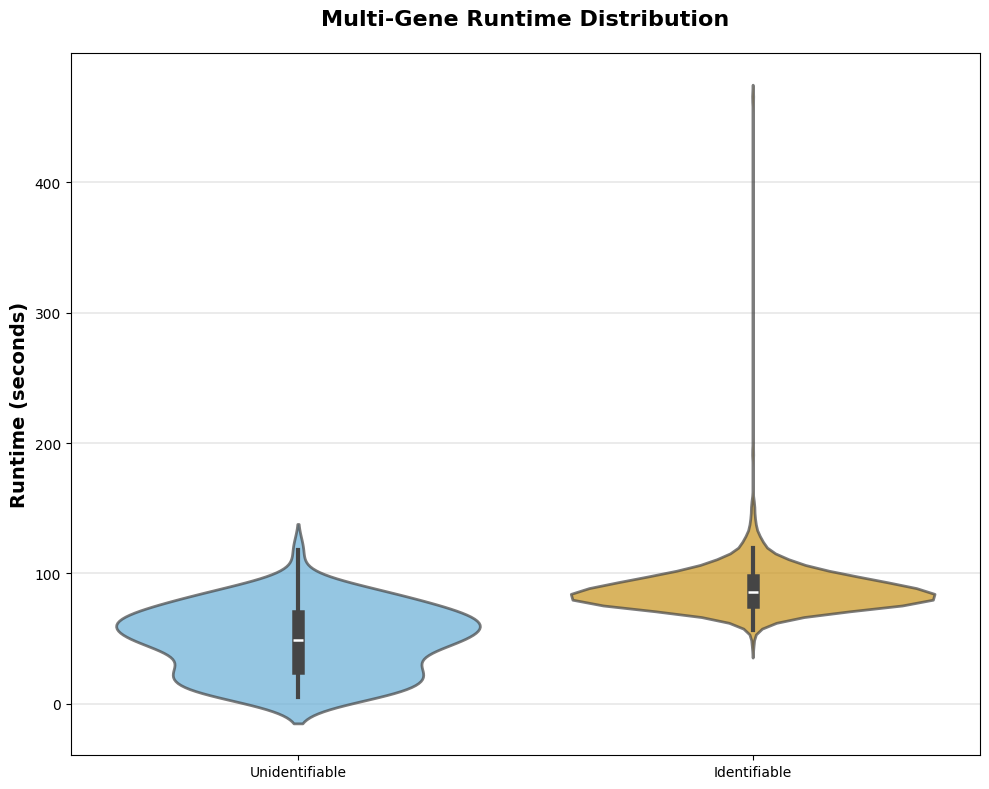


Unidentifiable: n=107 (10.7%)
  Median: 49.2s

Identifiable: n=893 (89.3%)
  Median: 85.5s


In [35]:
# ============================================================================
# Multi-Gene Runtime Distribution: Violin Plot (NO TEXT BOXES)
# ============================================================================

display(Markdown("## Multi-Gene Runtime Distribution (5→5)"))

import pandas as pd
import seaborn as sns

# Load the data
df_multigene = pd.read_csv("ecoli_5x5_1000samples_FINAL.csv")

# Prepare data
runtime_data = df_multigene[["runtime_seconds", "identifiable"]].copy()
runtime_data["Result"] = runtime_data["identifiable"].map(
    {True: "Identifiable", False: "Unidentifiable"}
)

# Create figure
fig, ax = plt.subplots(figsize=(10, 8))

# COLOR-BLIND FRIENDLY PALETTE
colorblind_palette = {"Identifiable": "#E69F00", "Unidentifiable": "#56B4E9"}  # Orange  # Sky Blue

# Plot with Unidentifiable FIRST (left)
sns.violinplot(
    data=runtime_data,
    x="Result",
    y="runtime_seconds",
    order=["Unidentifiable", "Identifiable"],
    palette=colorblind_palette,
    ax=ax,
    inner="box",
    linewidth=2,
    alpha=0.7,
)

ax.set_ylabel("Runtime (seconds)", fontsize=14, fontweight="bold")
ax.set_xlabel("")
ax.set_title("Multi-Gene Runtime Distribution", fontsize=16, fontweight="bold", pad=20)
ax.grid(axis="y", alpha=0.3, linewidth=1.2)
ax.set_axisbelow(True)

plt.tight_layout()

# Save
fig_filename = "ecoli_multigene_5x5_violin_clean.png"
plt.savefig(fig_filename, dpi=300, bbox_inches="tight", facecolor="white")
display(Markdown(f"**✓ Clean multi-gene violin plot saved:** `{fig_filename}`"))
plt.show()

# Print stats separately
print(
    f"\nUnidentifiable: n={runtime_data[runtime_data['Result'] == 'Unidentifiable'].shape[0]} (10.7%)"
)
print(
    f"  Median: {runtime_data[runtime_data['Result'] == 'Unidentifiable']['runtime_seconds'].median():.1f}s"
)

print(
    f"\nIdentifiable: n={runtime_data[runtime_data['Result'] == 'Identifiable'].shape[0]} (89.3%)"
)
print(
    f"  Median: {runtime_data[runtime_data['Result'] == 'Identifiable']['runtime_seconds'].median():.1f}s"
)